In [1]:
import sys
sys.path.append("..")
from src.ingest.build import load_raw
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

df_x, df_y, df_z = load_raw()

series = {}
for nombre, df in [("X", df_x), ("Y", df_y), ("Z", df_z)]:
    series[nombre] = df.set_index("Date")[f"Price_{nombre}"].sort_index().resample("ME").mean()

inicio = max(s.index.min() for s in series.values())
series = {k: s[s.index >= inicio] for k, s in series.items()}

for nombre, s in series.items():
    print(nombre, s.index.min().date(), "→", s.index.max().date(), len(s))
fin_comun = min(s.index.max() for s in series.values())
corte = fin_comun - pd.DateOffset(months=12)
print("fin común:", fin_comun.date(), "| corte:", corte.date())

X 2010-01-31 → 2024-04-30 172
Y 2010-01-31 → 2023-09-30 165
Z 2010-01-31 → 2023-08-31 164
fin común: 2023-08-31 | corte: 2022-08-31


In [3]:
from src.forecast.commodities import backtest, ranking

cortes = pd.to_datetime(["2019-08-31", "2020-08-31", "2021-08-31", "2022-08-31"])
bt = backtest(series, cortes)
rk = ranking(bt)
rk.round(4)

21:51:10 - cmdstanpy - INFO - Chain [1] start processing
21:51:10 - cmdstanpy - INFO - Chain [1] done processing
21:51:10 - cmdstanpy - INFO - Chain [1] start processing
21:51:10 - cmdstanpy - INFO - Chain [1] done processing
21:51:10 - cmdstanpy - INFO - Chain [1] start processing
21:51:10 - cmdstanpy - INFO - Chain [1] done processing
21:51:11 - cmdstanpy - INFO - Chain [1] start processing
21:51:11 - cmdstanpy - INFO - Chain [1] done processing
21:51:11 - cmdstanpy - INFO - Chain [1] start processing
21:51:11 - cmdstanpy - INFO - Chain [1] done processing
21:51:11 - cmdstanpy - INFO - Chain [1] start processing
21:51:11 - cmdstanpy - INFO - Chain [1] done processing
21:51:11 - cmdstanpy - INFO - Chain [1] start processing
21:51:12 - cmdstanpy - INFO - Chain [1] done processing
21:51:12 - cmdstanpy - INFO - Chain [1] start processing
21:51:12 - cmdstanpy - INFO - Chain [1] done processing
21:51:12 - cmdstanpy - INFO - Chain [1] start processing
21:51:12 - cmdstanpy - INFO - Chain [1]

,serie,h,modelo,MAPE,RMSE,MASE,ganador
3,X,3,lightgbm,0.0595,4.9412,0.9642,True
4,X,3,naive,0.0686,5.3425,1.1666,False
2,X,3,ets,0.0679,5.4063,1.1760,False
1,X,3,drift,0.0679,5.4063,1.1760,False
0,X,3,arima,0.0836,6.0930,1.3713,False
...,...,...,...,...,...,...,...
62,Z,12,sarima,0.1058,316.0181,3.7926,False
56,Z,12,arima,0.1077,314.7844,3.8192,False
58,Z,12,ets,0.1077,314.1353,3.8519,False
57,Z,12,drift,0.1077,314.1362,3.8519,False


In [7]:
rk[(rk.serie == "X") & (rk.h == 12)].round(4)

,serie,h,modelo,MAPE,RMSE,MASE,ganador
17,X,12,lightgbm,0.2470,20.0439,3.8674,True
14,X,12,arima,0.2473,19.3803,3.9501,False
18,X,12,naive,0.2529,19.7835,3.9685,False
20,X,12,sarima,0.2483,19.6468,4.0077,False
16,X,12,ets,0.2568,20.3279,4.0798,False
15,X,12,drift,0.2568,20.3279,4.0798,False
19,X,12,prophet,0.3193,26.5075,5.7703,False


In [8]:
rk[rk.h == 3].round(4)

,serie,h,modelo,MAPE,RMSE,MASE,ganador
3,X,3,lightgbm,0.0595,4.9412,0.9642,True
4,X,3,naive,0.0686,5.3425,1.1666,False
2,X,3,ets,0.0679,5.4063,1.1760,False
1,X,3,drift,0.0679,5.4063,1.1760,False
0,X,3,arima,0.0836,6.0930,1.3713,False
6,X,3,sarima,0.0895,6.6442,1.4771,False
5,X,3,prophet,0.2381,18.5130,4.2675,False
21,Y,3,arima,0.0572,41.3030,1.4948,True
27,Y,3,sarima,0.0620,43.4683,1.5918,False
25,Y,3,naive,0.0635,45.4677,1.6506,False


In [6]:
rk[rk['ganador'] == True]

,serie,h,modelo,MAPE,RMSE,MASE,ganador
3,X,3,lightgbm,0.059528,4.941200,0.964197,True
10,X,6,lightgbm,0.091279,8.176590,1.505310,True
17,X,12,lightgbm,0.247016,20.043859,3.867391,True
21,Y,3,arima,0.057189,41.302970,1.494759,True
34,Y,6,sarima,0.080562,64.027440,2.364869,True
41,Y,12,sarima,0.134950,119.621759,4.484053,True
48,Z,3,sarima,0.044786,123.271241,1.562996,True
53,Z,6,naive,0.062629,182.958123,2.258889,True
59,Z,12,lightgbm,0.098387,304.718172,3.671436,True


#### Selección de modelo y horizonte

Se evaluaron siete modelos sobre cuatro ventanas de corte (2019 a 2022) y tres horizontes (3, 6 y 12 meses), con MAPE, RMSE y MASE. Se descarta R², no es relevante para pronóstico de series de tiempo.

##### Horizonte

El error con el horizonte en las tres series.

| Serie | MAPE h=3 | MAPE h=12 |
|---|---|---|
| X | 6.0% | 24.7% |
| Y | 5.7% | 13.5% |
| Z | 4.5% | 9.8% |

A 12 meses ningún modelo se distingue del resto. Todos quedan entre 24.7% y 25.7% en X, y el MASE supera 3.8, es decir, el error es casi cuatro veces el cambio típico mes a mes. Se adopta un horizonte de 3 meses como base de planeación, con 6 meses como escenario extendido de mayor
incertidumbre.

##### Modelo por serie (h=3)

El criterio de selección es doble: gana el modelo que lidere al menos dos de las tres métricas y que mejore el MASE del naive en al menos 5%. Si ningún modelo cumple ambas condiciones se conserva el naive, porque la ganancia no justifica la complejidad adicional.

| Serie | Modelo | MAPE | MASE | Mejora sobre naive |
|---|---|---|---|---|
| X | LightGBM | 5.95% | 0.96 | 17.4% |
| Y | ARIMA(1,1,1) | 5.72% | 1.49 | 9.4% |
| Z | SARIMA(1,1,1)(1,0,1,12) | 4.48% | 1.56 | 7.6% |


La selección se ejecuta en `make train` y queda registrada en `models/seleccion.json` junto con las métricas y la fecha, de modo que el pronóstico no depende de valores quemados y cualquier cambio en los datos se refleja al reentrenar.

In [10]:
import pandas as pd
out = pd.read_csv("../data/forecasts/pronostico_extendido_6m.csv")
out.pivot(index="h", columns="serie", values="ancho_rel")

serie,Equipo1,Equipo2,X,Y,Z
h,,,,,
1,0.1325,0.1740,0.1520,0.1320,0.1857
2,0.1516,0.1892,0.3212,0.1503,0.1999
3,0.2798,0.1886,0.1831,0.2907,0.1735
4,0.4551,0.1973,0.2428,0.4654,0.1674
5,0.4619,0.1591,0.4837,0.4682,0.1745
6,0.3984,0.2357,0.5762,0.4088,0.2950


## Pronóstico final

El pronóstico parte de agosto de 2023, último mes con las tres materias primas disponibles. Cada serie se proyecta con su modelo ganador y los precios de los equipos se obtienen aplicando las fórmulas validadas, sin estimar un modelo adicional. La incertidumbre se propaga por bootstrap de los errores del backtest: se simulan 2000 trayectorias remuestreando los errores relativos que cada modelo cometió en cada ventana de corte, tomando la misma ventana para las tres materias primas de modo que su correlación se preserve al combinarlas. Los intervalos reportados son los percentiles 5 y 95. El número de ventanas se amplió de cuatro a nueve (una por año desde 2014) al observar que con cuatro el ancho del intervalo no crecía de forma monótona con el horizonte y la selección de modelo cambiaba según la ventana.

| Equipo | Sep 2023 | Oct 2023 | Nov 2023 |
|---|---|---|---|
| Equipo 1 | 458 [416, 479] | 447 [392, 472] | 425 [369, 539] |
| Equipo 2 | 930 [859, 995] | 923 [860, 1019] | 923 [842, 1014] |

El intervalo del Equipo 2 es más estrecho que el del Equipo 1 en todo el horizonte, consecuencia directa de las fórmulas: el Equipo 2 promedia tres materias primas y la diversificación reduce la varianza, mientras el Equipo 1 concentra el 80% de su composición en una sola serie.

Se recomienda un horizonte de planeación de 3 meses. El ancho relativo del intervalo del Equipo 1 pasa de 14% en el primer mes a 40% en el tercero y supera 60% en el sexto. A partir del cuarto mes el rango deja de ser útil para presupuestar, porque el límite inferior y el superior implican decisiones de compra distintas. El escenario de 6 meses se reporta como referencia de tendencia, no como base presupuestal.

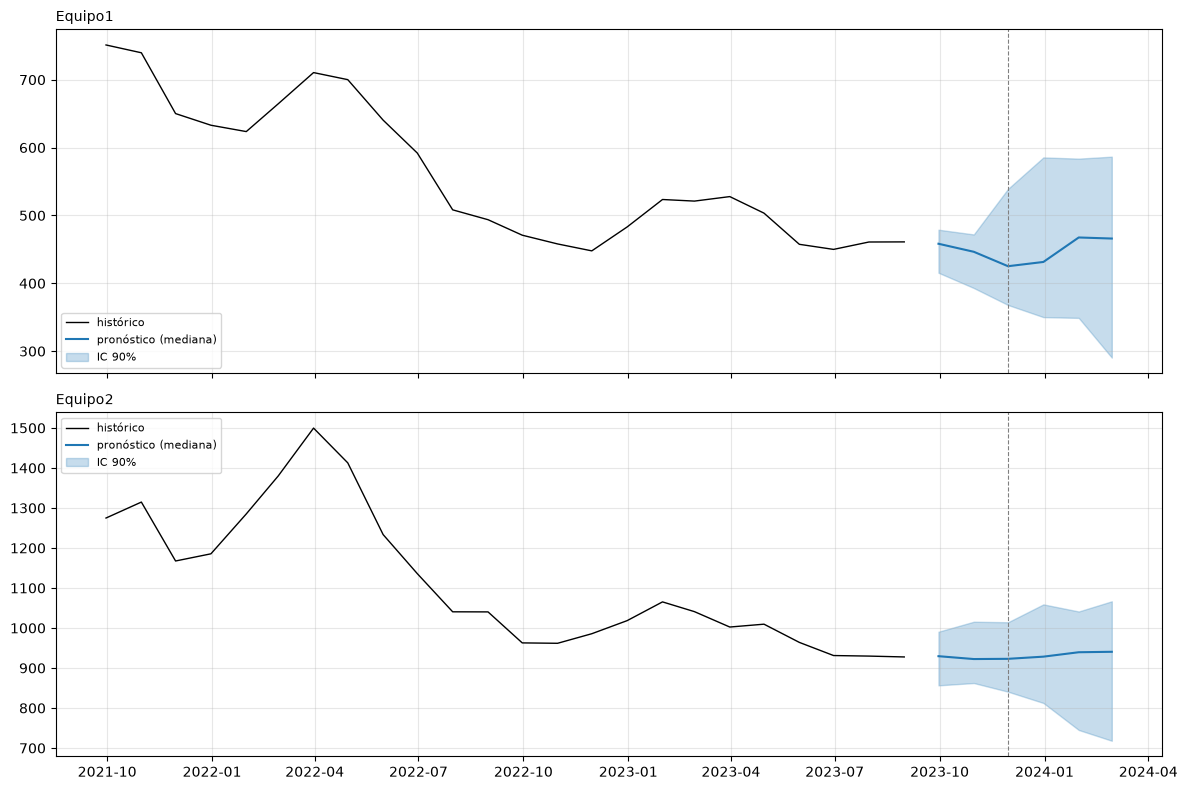

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

fc = pd.read_csv("../data/forecasts/pronostico_extendido_6m.csv", parse_dates=["fecha"])
hist = pd.read_csv("../data/processed/historico.csv", parse_dates=["Date"]).set_index("Date").resample("ME").mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, eq in zip(axes, ["Equipo1", "Equipo2"]):
    h24 = hist[f"Price_{eq}"].tail(24)
    ax.plot(h24.index, h24, color="black", linewidth=1, label="histórico")
    f = fc[fc.serie == eq]
    ax.plot(f.fecha, f.p50, color="tab:blue", linewidth=1.5, label="pronóstico (mediana)")
    ax.fill_between(f.fecha, f.p5, f.p95, alpha=0.25, color="tab:blue", label="IC 90%")
    ax.axvline(f.fecha.iloc[2], color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(eq, loc="left", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../reports/figures/pronostico_equipos.png", dpi=150, bbox_inches="tight")

In [13]:
import numpy as np
from src.forecast.commodities import MODELOS
import json
from src.ingest.build import load_raw

dfs = load_raw()
series_completas = {}
for nombre, df in zip(["X", "Y", "Z"], dfs):
    s = df.set_index("Date")[f"Price_{nombre}"].sort_index().resample("ME").mean()
    series_completas[nombre] = s

inicio = max(s.index.min() for s in series_completas.values())
series_completas = {k: s[s.index >= inicio] for k, s in series_completas.items()}

ganadores = json.loads(open("../models/seleccion.json").read())["ganadores"]
origen = "2023-08-31"

for nombre in ["X", "Y"]:
    s = series_completas[nombre]          # la serie SIN recortar al período común
    tr = s[s.index <= origen]
    te = s[s.index > origen]
    pred = MODELOS[ganadores[nombre]](tr, len(te))
    mape = np.mean(np.abs((te.to_numpy() - pred) / te.to_numpy()))
    print(f"{nombre}: {len(te)} meses reales | modelo {ganadores[nombre]} | MAPE {mape:.2%}")

X: 8 meses reales | modelo naive | MAPE 5.30%
Y: 1 meses reales | modelo arima | MAPE 0.94%


#### Validación out-of-sample

Los archivos crudos de X e Y contienen meses posteriores al último dato del histórico entregado:
X llega hasta abril de 2024 y Y hasta septiembre de 2023, mientras el período común termina en
agosto de 2023. Esos meses no intervinieron en la selección de modelo ni en el entrenamiento, por
lo que constituyen un holdout genuino.

| Serie | Meses | Modelo | MAPE |
|---|---|---|---|
| X | 8 | naive | 5.30% |
| Y | 1 | ARIMA | 0.94% |

El error de X sobre ocho meses no vistos (5.30%) es menor que el obtenido en el backtest a tres
meses (7.85%), lo que respalda la metodología. Z no admite esta validación porque su última
observación coincide con el fin del período común, y los equipos tampoco, ya que requieren las
tres materias primas simultáneamente.

In [19]:
from src.agent.tools import analisis_sensibilidad, presupuesto_proyecto, estado_pipeline
print(analisis_sensibilidad.invoke({"materia_prima": "Y", "shock_pct": 15}))
print()
print(presupuesto_proyecto.invoke({"compras": "1:2:1, 2:1:3", "percentil": "p95"}))
print()
print(estado_pipeline.invoke({}))

Impacto de una variación de +15% en Y, a 3 meses:

Equipo1 (peso de Y: 0.80):
  2023-09-30: 458 -> 524 (+14.4%)
  2023-10-31: 447 -> 511 (+14.4%)
  2023-11-30: 425 -> 486 (+14.5%)

Equipo2 (peso de Y: 0.33):
  2023-09-30: 930 -> 957 (+3.0%)
  2023-10-31: 923 -> 949 (+2.9%)
  2023-11-30: 923 -> 948 (+2.8%)

Presupuesto con escenario p95:
  Equipo1 x2 en 2023-09-30: 479 c/u = 958
  Equipo2 x1 en 2023-11-30: 1014 c/u = 1,014

Total: 1,972
Este total corresponde al escenario alto. Con el percentil 50 se obtiene el costo esperado y con el 5 el escenario favorable

Estado del pipeline:
  Histórico procesado: 3530 registros diarios, de 2010-01-04 a 2023-08-31
  Selección de modelo: generada el 2026-09-11, ganadores {'X': 'naive', 'Y': 'arima', 'Z': 'sarima'}
  Pronósticos disponibles: pronostico_base_3m.csv, pronostico_extendido_6m.csv
